
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Ahmed Yehia Elkammar/2026 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [41]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt

import seaborn as sb

%matplotlib inline

In [42]:
# Load my dataset using pandas Dataframe
df =pd.read_csv('C:/Games/fordgobike-tripdataFor201902.csv')


In [43]:
# here we make overview in high-level for data shape and composition
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Number of rows: 183416
Number of columns: 16

Dataset shape: (183416, 16)

Column names:
['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'member_gender', 'bike_share_for_all_trip']


In [44]:
## check each var  datatype 
print(df.dtypes)


duration_sec                 int64
start_time                     str
end_time                       str
start_station_id           float64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name               str
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                      str
member_birth_year          float64
member_gender                  str
bike_share_for_all_trip        str
dtype: object


In [45]:
## I display 15 rows to understand the content values more 
df.head(15)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [46]:
# descriptive statistics for numeric variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_sec,183416.0,726.067311,1794.371831,61.000000,325.000000,514.000000,796.000000,85444.000000
start_station_id,183219.0,138.590365,111.778938,3.000000,47.000000,104.000000,239.000000,398.000000
start_station_latitude,183416.0,37.771221,0.099586,37.317298,37.770083,37.780760,37.797280,37.880222
start_station_longitude,183416.0,-122.352661,0.117100,-122.453705,-122.412408,-122.398285,-122.286533,-121.874119
end_station_id,183219.0,136.249401,111.514916,3.000000,44.000000,100.000000,235.000000,398.000000
end_station_latitude,183416.0,37.771425,0.099494,37.317298,37.770407,37.781010,37.797320,37.880222
end_station_longitude,183416.0,-122.352247,0.116677,-122.453705,-122.411726,-122.398279,-122.288045,-121.874119
bike_id,183416.0,4472.890260,1664.386068,11.000000,3777.000000,4958.000000,5502.000000,6645.000000
member_birth_year,175151.0,1984.806504,10.116589,1878.000000,1980.000000,1987.000000,1992.000000,2001.000000




> ### What is the structure of your dataset?





- The structure of the dataset contains  ..16... columns and ...183416.... rows.
 
 
- Most variables are (float/str) in nature , and here are **dtypes summary :**

        - float (7)
        - int (2)
        - str (7)
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
 
 
- 
duration_sec
 
 
 
- 
user_type
  
 
  
- 
member_gender




> ### What features in the dataset supported my investigation for these interesting features?



- 
start_time



- 
end_time



- start_station_id



-
end_station_id




- 
member_birth_year




##  More Exploring ideas to begin my investigation

In [47]:
#This code for describing statistical data ideas in a more organized and readable table

summary = df.describe().T
summary["missing_values"] = df.isna().sum()
summary["unique_values"] = df.nunique()
summary


,count,mean,std,min,25%,50%,75%,max,missing_values,unique_values
duration_sec,183416.0,726.067311,1794.371831,61.000000,325.000000,514.000000,796.000000,85444.000000,0,4752
start_station_id,183219.0,138.590365,111.778938,3.000000,47.000000,104.000000,239.000000,398.000000,197,329
start_station_latitude,183416.0,37.771221,0.099586,37.317298,37.770083,37.780760,37.797280,37.880222,0,334
start_station_longitude,183416.0,-122.352661,0.117100,-122.453705,-122.412408,-122.398285,-122.286533,-121.874119,0,335
end_station_id,183219.0,136.249401,111.514916,3.000000,44.000000,100.000000,235.000000,398.000000,197,329
end_station_latitude,183416.0,37.771425,0.099494,37.317298,37.770407,37.781010,37.797320,37.880222,0,335
end_station_longitude,183416.0,-122.352247,0.116677,-122.453705,-122.411726,-122.398279,-122.288045,-121.874119,0,335
bike_id,183416.0,4472.890260,1664.386068,11.000000,3777.000000,4958.000000,5502.000000,6645.000000,0,4646
member_birth_year,175151.0,1984.806504,10.116589,1878.000000,1980.000000,1987.000000,1992.000000,2001.000000,8265,75


In [48]:
# display the information about each column

print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [49]:
#yOUR CODES
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64



> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with .....(Median\mean)...... for numeric and ...(mode)...for categorical

In [50]:
# trying to fill missing values in my datset using for loop 

for col in df[['member_gender','user_type','bike_share_for_all_trip']]:
    df[col] = df[col].fillna(df[col].mode()[0])

    df['member_birth_year'] = df['member_birth_year'].fillna(df['member_birth_year'].median())

for col in df[['start_station_name','end_station_name']]:
    df[col] = df[col].fillna('unknown')

for col in df[['start_station_id','end_station_id']]:

    df[col] = df[col].fillna(0)





In [51]:
#check the Nulls 
df.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

### **And with a proper category for other (member gender)**

In [52]:
##  still got a missing value in the member_gender, so let's explore this column more 

df['member_gender'].value_counts()

member_gender
Male      138920
Female     40844
Other       3652
Name: count, dtype: int64

In [53]:
# fill  dataset with missing values.
    


In [54]:
print(df['member_gender'].head(15))

0       Male
1       Male
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13      Male
14      Male
Name: member_gender, dtype: str


In [55]:
## check my result above 
df.isnull().sum()


duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [56]:
##  check duplicate in dataset
df.duplicated().sum()


np.int64(4)

> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [57]:
### check the category columns that included object
obj_cols = df.select_dtypes(include=['object', 'category']).columns

for col in obj_cols:
    print(f"=== Column: {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n" + "-"*40 + "\n")

=== Column: start_time ===
start_time
12:19.2    16
33:48.5    16
56:50.8    16
07:52.7    15
07:21.5    15
           ..
08:50.4     1
59:17.5     1
15:36.4     1
47:33.4     1
54:09.0     1
Name: count, Length: 35783, dtype: int64

----------------------------------------

=== Column: end_time ===
end_time
22:24.4    20
21:24.5    16
34:21.9    16
59:26.1    16
57:33.4    16
           ..
02:57.0     1
00:11.0     1
43:00.6     1
42:55.8     1
38:09.0     1
Name: count, Length: 35767, dtype: int64

----------------------------------------

=== Column: start_station_name ===
start_station_name
Market St at 10th St                                         3904
San Francisco Caltrain Station 2  (Townsend St at 4th St)    3544
Berry St at 4th St                                           3052
Montgomery St BART Station (Market St at 2nd St)             2896
Powell St BART Station (Market St at 4th St)                 2760
                                                             ... 
Wi

C:\Users\ahmad\AppData\Local\Temp\ipykernel_7276\1584963845.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object', 'category']).columns


 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [58]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.

cols = ["user_type", "member_gender", "bike_share_for_all_trip"]
df[cols] = df[cols].astype('category')


In [59]:
## check your work 
df.dtypes


duration_sec                  int64
start_time                      str
end_time                        str
start_station_id            float64
start_station_name              str
start_station_latitude      float64
start_station_longitude     float64
end_station_id              float64
end_station_name                str
end_station_latitude        float64
end_station_longitude       float64
bike_id                       int64
user_type                  category
member_birth_year           float64
member_gender              category
bike_share_for_all_trip    category
dtype: object

In [60]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year
year = 2026
df['user_age'] = year - df['member_birth_year']
df[["member_birth_year", "user_age"]].describe().T


,count,mean,std,min,25%,50%,75%,max
member_birth_year,183416.0,1984.905346,9.896492,1878.0,1981.0,1987.0,1992.0,2001.0
user_age,183416.0,41.094654,9.896492,25.0,34.0,39.0,45.0,148.0


In [61]:
## check your work 
df[["member_birth_year", "user_age"]].describe().T


,count,mean,std,min,25%,50%,75%,max
member_birth_year,183416.0,1984.905346,9.896492,1878.0,1981.0,1987.0,1992.0,2001.0
user_age,183416.0,41.094654,9.896492,25.0,34.0,39.0,45.0,148.0


In [62]:
## change the new column age data type from float to int
df["user_age"] = df["user_age"].astype(int)



In [63]:
## create a function to know the average users ages
def average_age(data):

    return data["user_age"].mean()

print(f"Average users' age: {average_age(df)} years")

Average users' age: 41.09465368343002 years


In [64]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable
df["duration_min"] = df["duration_sec"] / 60



In [65]:
## I need to change the time from second to Houre  to be more usable
df["duration_hour"] = df["duration_sec"] / 3600


In [66]:
## check your work
df[["duration_sec", "duration_min","duration_hour"]].head()


,duration_sec,duration_min,duration_hour
0,52185,869.750000,14.495833
1,42521,708.683333,11.811389
2,61854,1030.900000,17.181667
3,36490,608.166667,10.136111
4,1585,26.416667,0.440278



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

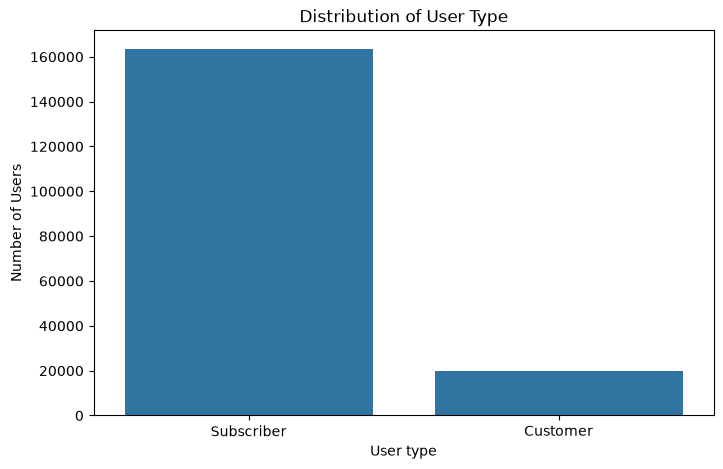

In [67]:
## I will import seaborn library to support me in making visualizations 

import seaborn as sns
import matplotlib.pyplot as plt
user_type_counts = df["user_type"].value_counts()

user_type_counts = df["user_type"].value_counts()
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="user_type", order=user_type_counts.index)
plt.xlabel("User type"); plt.ylabel("Number of Users"); plt.title("Distribution of User Type"); plt.show()




> ### <mark>Your analsys and exploration here </mark>
The distribution compares Subscribers and Customers. Most of the users are Subsribers .

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

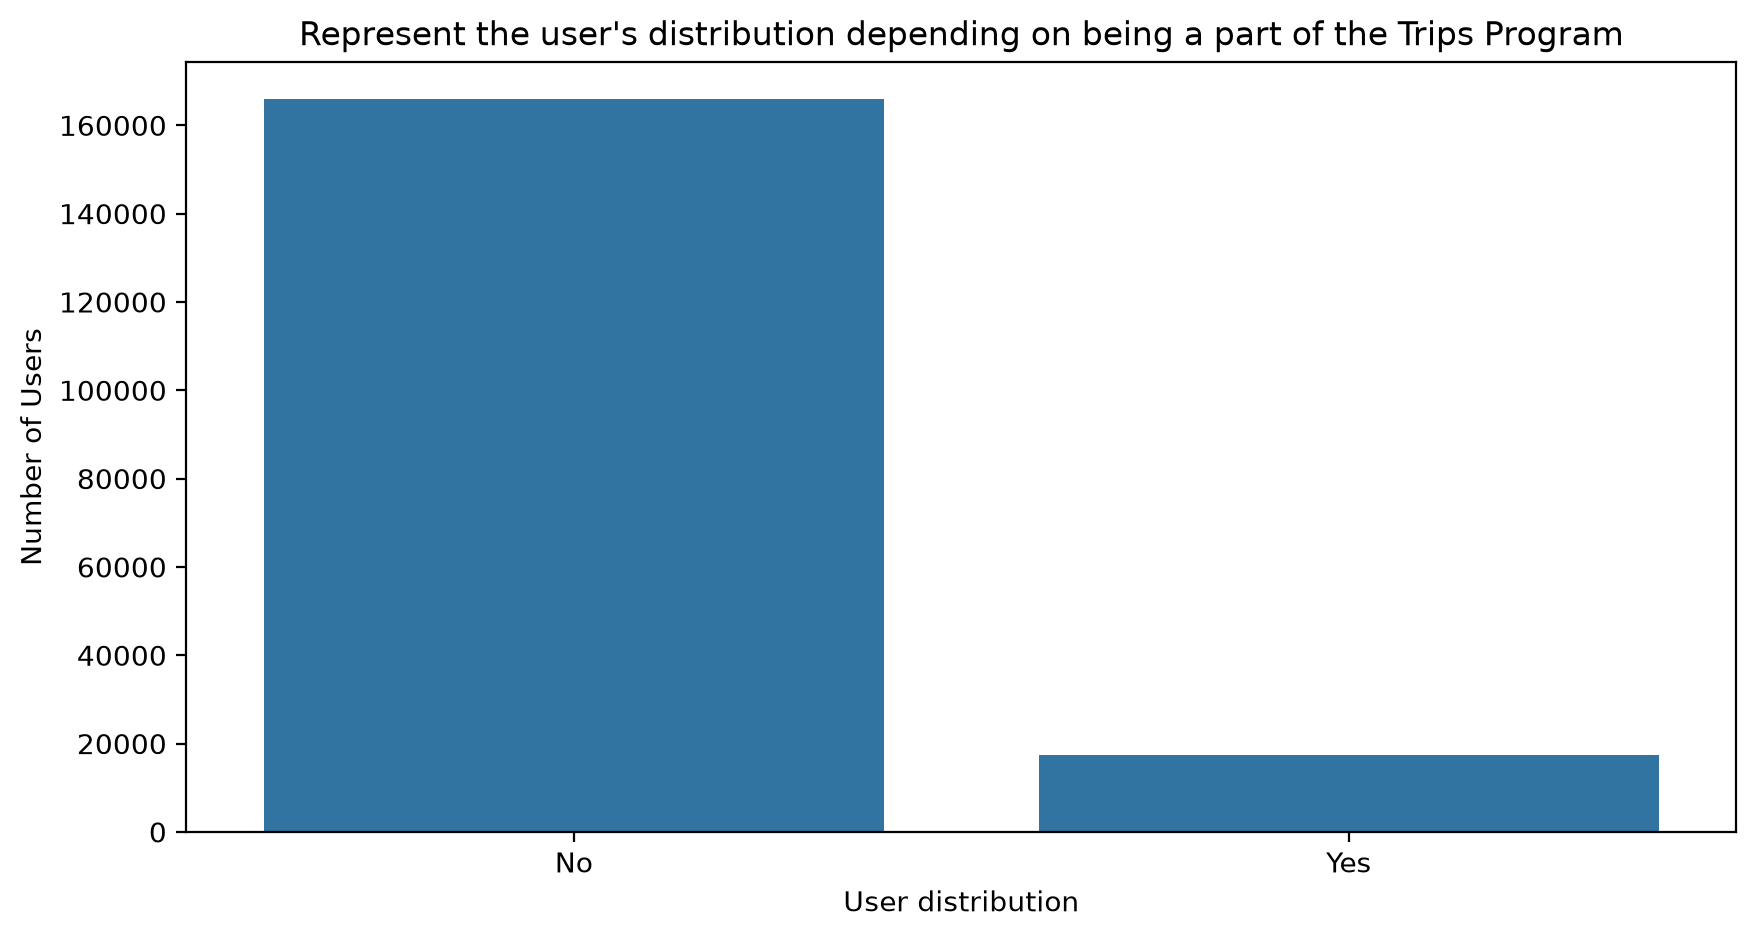

In [68]:

plt.figure(figsize = (10,5), dpi = 200)

plot = sns.countplot(data=df, x='bike_share_for_all_trip')

plt.xlabel('User distribution')
plt.ylabel('Number of Users')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")

plt.show()

> ### <mark>Your analsys and exploration here </mark>

Most of the  users are not part of the Trips Program . 

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

> ### <mark>Your analsys and exploration here </mark>

count    183416.000000
mean         41.094654
std           9.896492
min          25.000000
25%          34.000000
50%          39.000000
75%          45.000000
max         148.000000
Name: user_age, dtype: float64


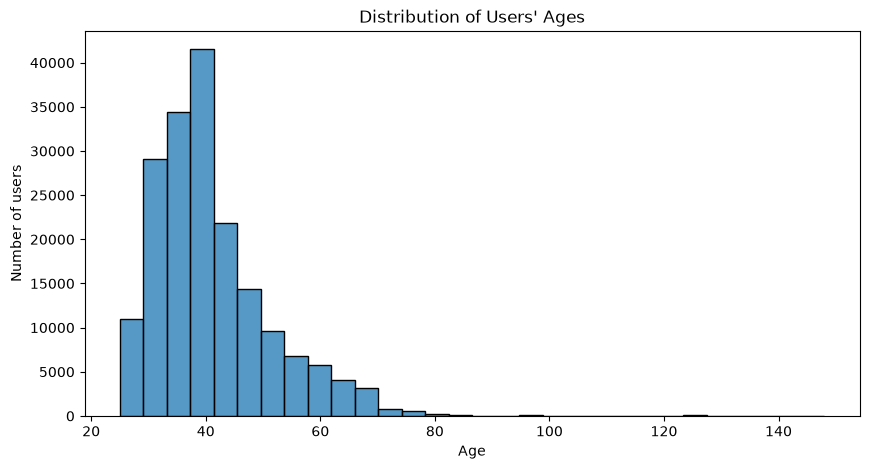

In [69]:
print(df["user_age"].describe())
plt.figure(figsize=(10, 5)); sns.histplot(data=df, x="user_age", bins=30)
plt.xlabel("Age"); plt.ylabel("Number of users"); plt.title("Distribution of Users' Ages"); plt.show()


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


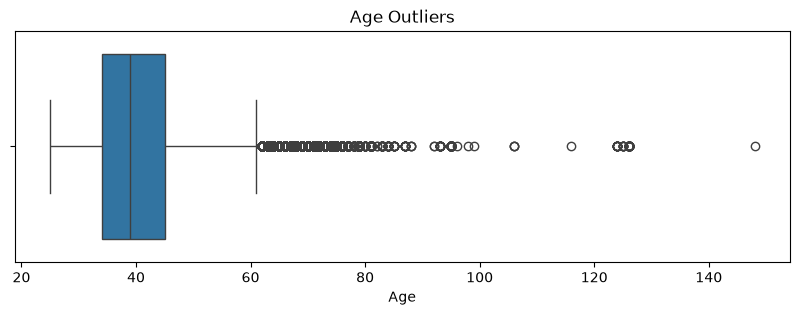

In [70]:
q1 = df["user_age"].quantile(0.25); q3 = df["user_age"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr; upper_bound = q3 + 1.5 * iqr
age_outliers = df[(df["user_age"] < lower_bound) | (df["user_age"] > upper_bound)]

plt.figure(figsize=(10, 3)); sns.boxplot(x=df["user_age"]); plt.xlabel("Age"); plt.title("Age Outliers"); plt.show()

> ### <mark>Your analsys and exploration here </mark>

the data has alot of outliers , most of the outliers are older than 60 years .

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [71]:
## Review the statistic for trip duration in minutes
print(df["duration_min"].describe())


count    183416.000000
mean         12.101122
std          29.906197
min           1.016667
25%           5.416667
50%           8.566667
75%          13.266667
max        1424.066667
Name: duration_min, dtype: float64


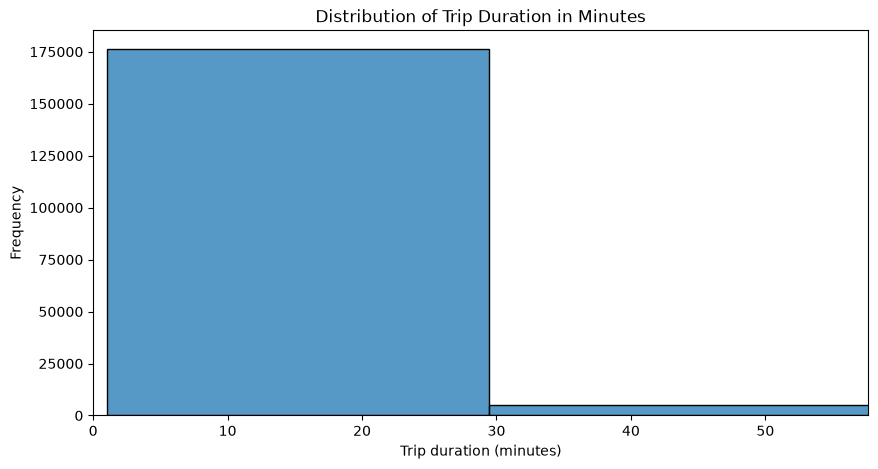

In [72]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 5)); sns.histplot(data=df, x="duration_min", bins=50)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Frequency"); plt.title("Distribution of Trip Duration in Minutes")
plt.xlim(0, df["duration_min"].quantile(0.99)); plt.show()

> ### <mark>Your analsys and exploration here </mark>

most of the trips are less than 30 mintes


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

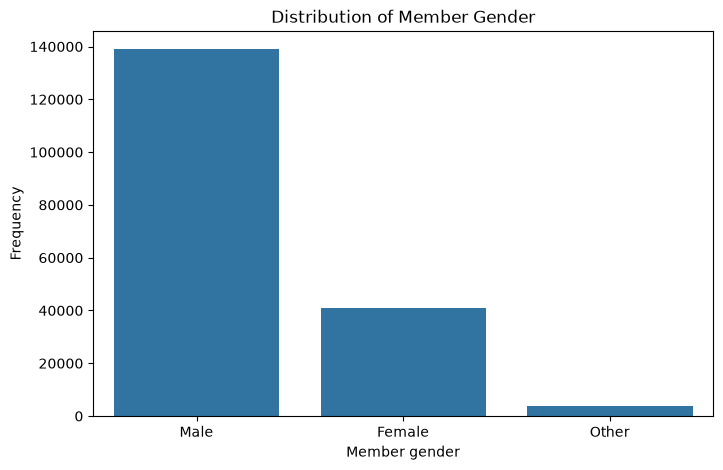

In [73]:
# Make visualization to easy get insight
gender_counts = df["member_gender"].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="member_gender", order=gender_counts.index)
plt.xlabel("Member gender"); plt.ylabel("Frequency")
plt.title("Distribution of Member Gender")
plt.show()

> ### <mark>Your analsys and exploration here </mark>
most of the users are males , females are less and there is a little that refused to choose thier gender

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

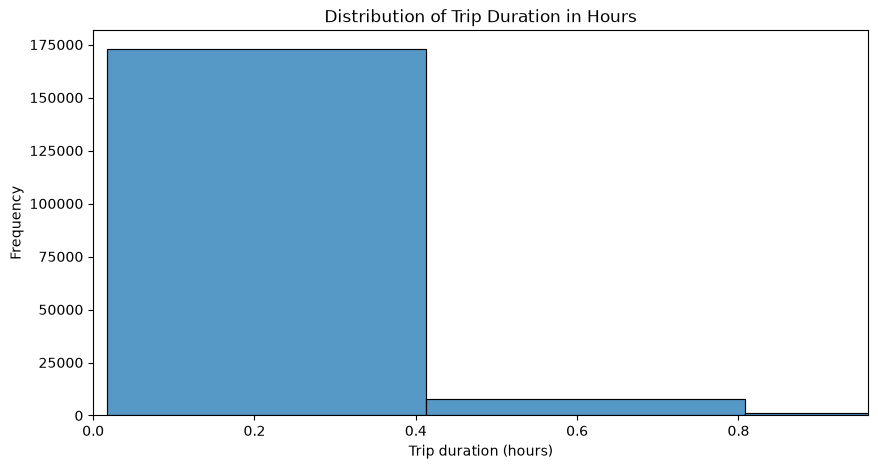

In [74]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="duration_hour", bins=60)
plt.xlabel("Trip duration (hours)")
plt.ylabel("Frequency"); plt.title("Distribution of Trip Duration in Hours")
plt.xlim(0, df["duration_hour"].quantile(0.99))
plt.show()

> ### <mark>Your analsys and exploration here </mark>
most of the trips are less than half an hour


### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [75]:
# Distribution of Age by user types
avg_duration_user = df.groupby("user_type")["duration_min"].mean()
print(avg_duration_user)


user_type
Customer      23.874417
Subscriber    10.670888
Name: duration_min, dtype: float64


# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

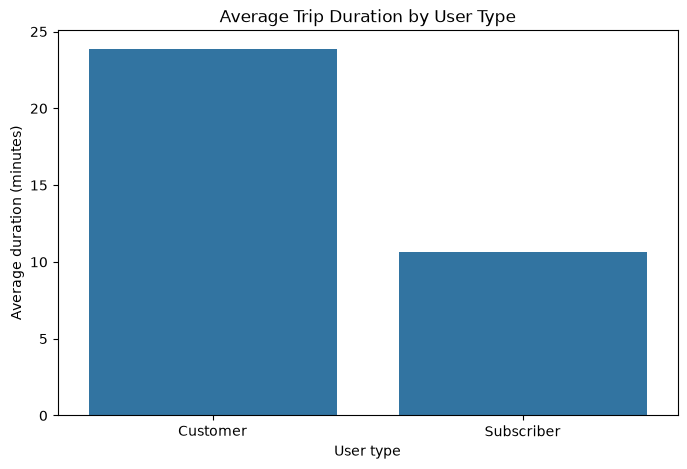

In [76]:
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_duration_user.index, y=avg_duration_user.values)
plt.xlabel("User type")
plt.ylabel("Average duration (minutes)")
plt.title("Average Trip Duration by User Type")
plt.show()

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

In [77]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender
average_duration_gender = df.groupby('member_gender')['duration_min'].mean()

print(average_duration_gender)

member_gender
Female    12.984506
Male      11.722903
Other     16.608589
Name: duration_min, dtype: float64


# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

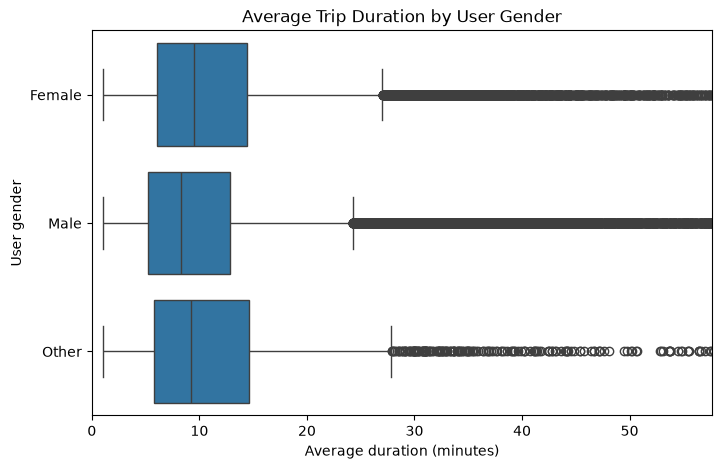

In [78]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="duration_min", y="member_gender")
plt.xlabel("Average duration (minutes)")
plt.ylabel("User gender")
plt.title("Average Trip Duration by User Gender")
plt.xlim(0, df["duration_min"].quantile(0.99))
plt.show()

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

               count       mean        std       min  25%        50%    75%  \
user_type                                                                     
Customer     19868.0  23.874417  64.355239  1.033333  8.4  13.200000  21.05   
Subscriber  163548.0  10.670888  21.932709  1.016667  5.2   8.166667  12.50   

                    max  
user_type                
Customer    1396.200000  
Subscriber  1424.066667  


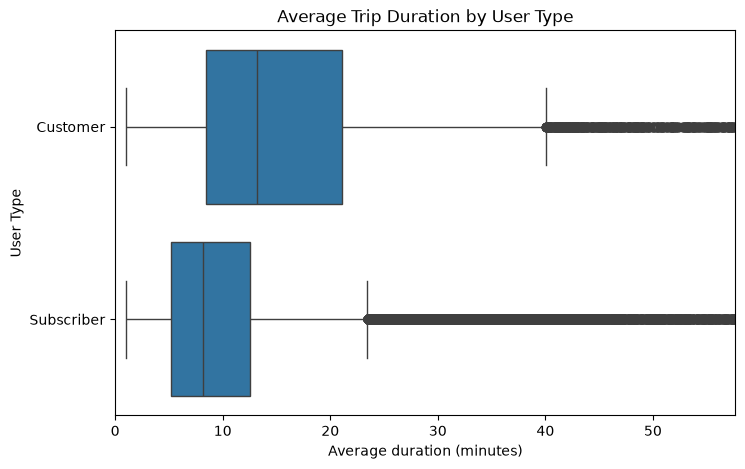

In [102]:

# Make visualization to easy get insight
print(df.groupby("user_type", )["duration_min"].describe())
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="duration_min", y="user_type")
plt.xlabel("Average duration (minutes)")
plt.ylabel("User Type")
plt.title("Average Trip Duration by User Type")
plt.xlim(0, df["duration_min"].quantile(0.99))
plt.show()



> ### <mark>Your analsys and exploration here </mark>

the customer data have outliers after 40 min , the customer data have outliers after 25 min and customers have longer trip duration

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

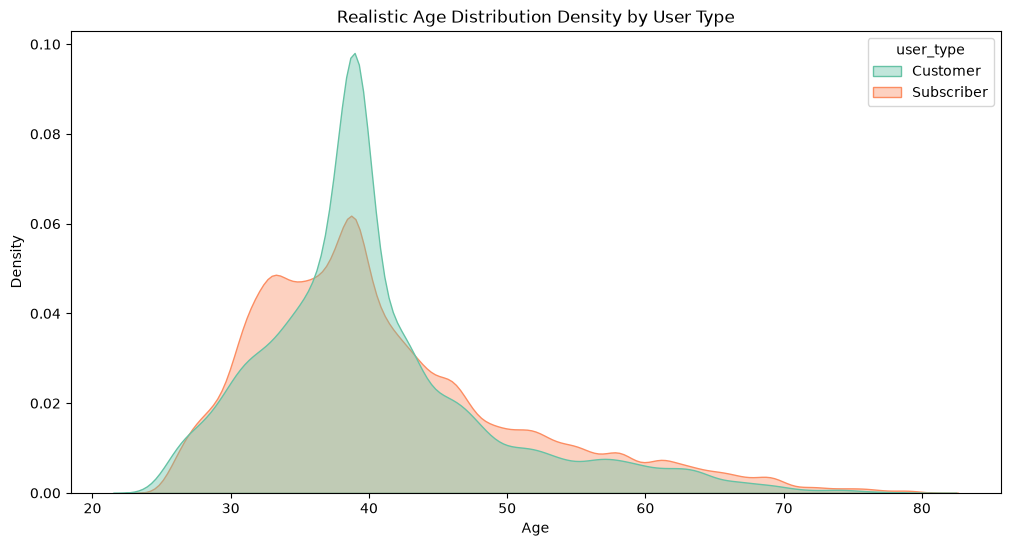

In [ ]:


df_filtered = df[df["user_age"] <= 80]


plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=df_filtered, 
    x="user_age", 
    hue="user_type", 
    common_norm=False, 
    fill=True, 
    alpha=0.4,    
    palette="Set2"
)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Realistic Age Distribution Density by User Type")
plt.show()




> ### <mark>Your analsys and exploration here </mark>



#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

member_gender  Female   Male  Other
user_age                           
25                 18     16      0
26                427   1249      2
27                588   1933      7
28                587   2605     16
29                772   2582    127
30               1450   3098     92
31               1619   5667    137
32               1434   6157     69
33               2080   7067    178
34               2423   5708    119
35               2462   5891    145
36               2656   5858    145
37               2505   6306    162
38               2483   7555    199
39               1775  14314    194
40               2125   5690    158
41               1720   5188    120
42               1460   4926    177
43               1285   4439    230
44               1174   3734     82


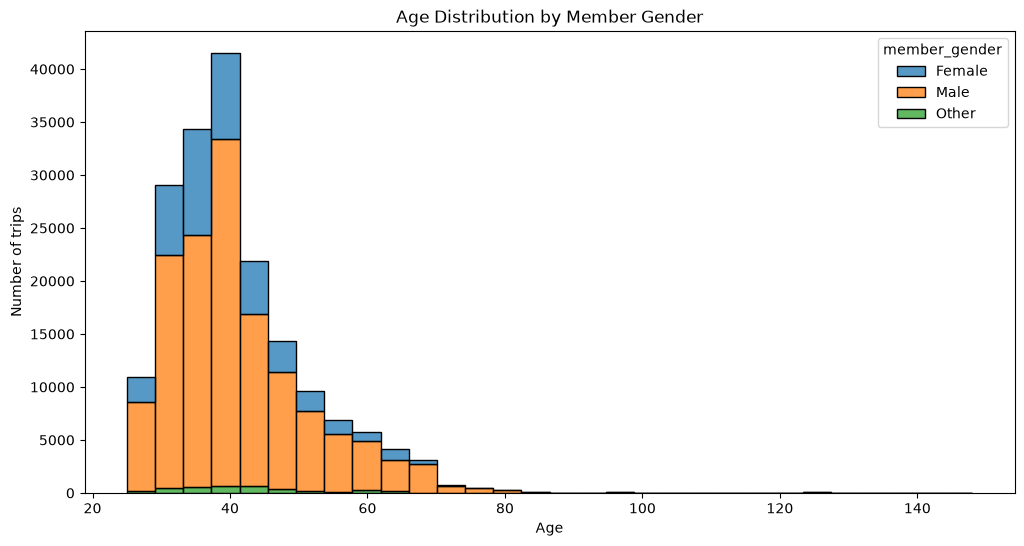

In [116]:
# Make visualization to easy get insight
age_gender_counts = pd.crosstab(df["user_age"], df["member_gender"])
print(age_gender_counts.head(20))
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="user_age", hue="member_gender", bins=30, multiple="stack")
plt.xlabel("Age"); plt.ylabel("Number of trips")
plt.title("Age Distribution by Member Gender"); plt.show()

> ### <mark>Your analsys and exploration here </mark>

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> ...................


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> ....................

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

In [119]:
## check your work 
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes); print("\nRemaining missing values:", df.isna().sum().sum())


Shape: (183416, 19)

Data types:
duration_sec                  int64
start_time                      str
end_time                        str
start_station_id            float64
start_station_name              str
start_station_latitude      float64
start_station_longitude     float64
end_station_id              float64
end_station_name                str
end_station_latitude        float64
end_station_longitude       float64
bike_id                       int64
user_type                  category
member_birth_year           float64
member_gender              category
bike_share_for_all_trip    category
user_age                      int64
duration_min                float64
duration_hour               float64
dtype: object

Remaining missing values: 0



# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

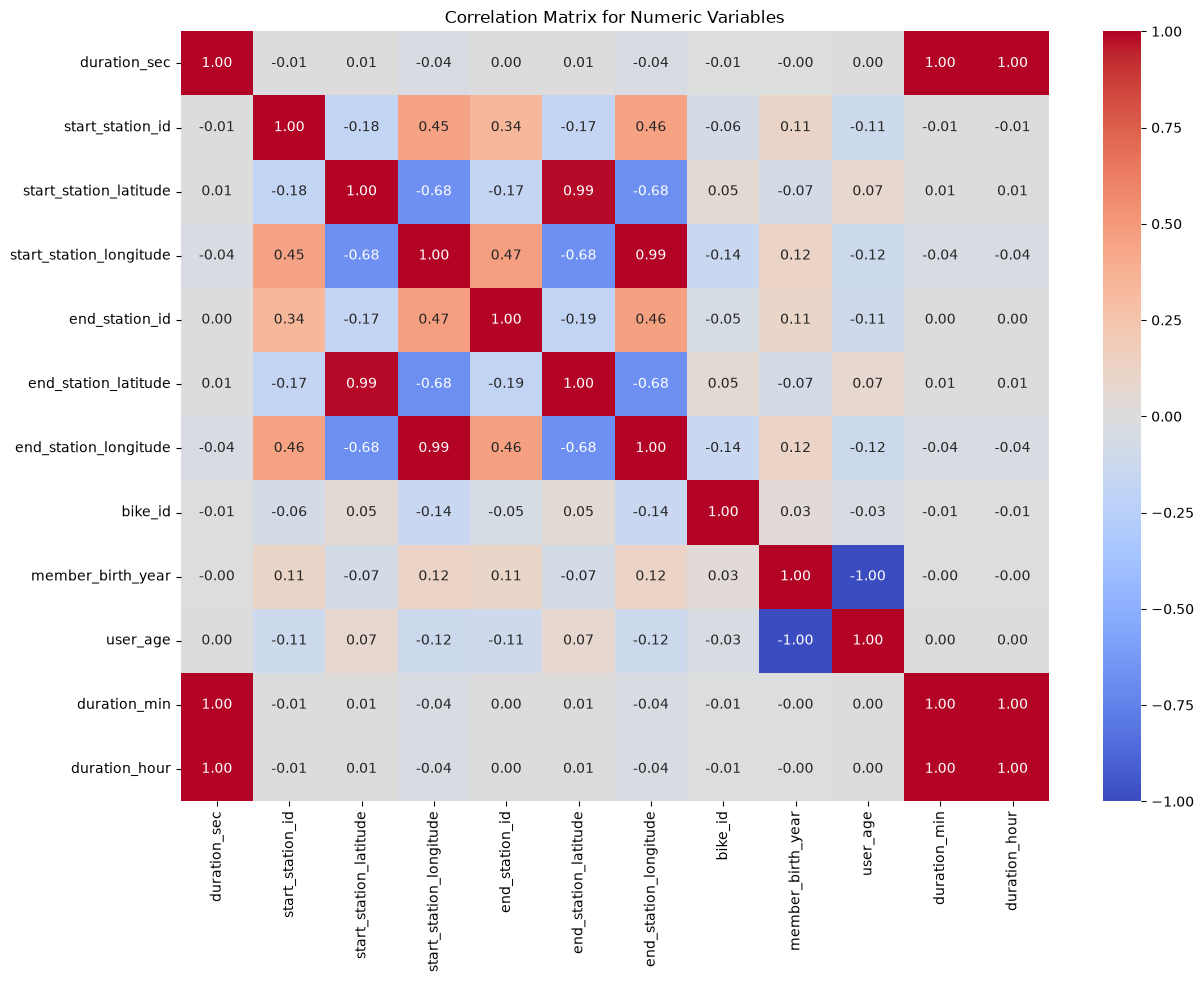

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,user_age,duration_min,duration_hour
duration_sec,1.00,-0.01,0.01,-0.04,0.00,0.01,-0.04,-0.01,-0.00,0.00,1.00,1.00
start_station_id,-0.01,1.00,-0.18,0.45,0.34,-0.17,0.46,-0.06,0.11,-0.11,-0.01,-0.01
start_station_latitude,0.01,-0.18,1.00,-0.68,-0.17,0.99,-0.68,0.05,-0.07,0.07,0.01,0.01
start_station_longitude,-0.04,0.45,-0.68,1.00,0.47,-0.68,0.99,-0.14,0.12,-0.12,-0.04,-0.04
end_station_id,0.00,0.34,-0.17,0.47,1.00,-0.19,0.46,-0.05,0.11,-0.11,0.00,0.00
end_station_latitude,0.01,-0.17,0.99,-0.68,-0.19,1.00,-0.68,0.05,-0.07,0.07,0.01,0.01
end_station_longitude,-0.04,0.46,-0.68,0.99,0.46,-0.68,1.00,-0.14,0.12,-0.12,-0.04,-0.04
bike_id,-0.01,-0.06,0.05,-0.14,-0.05,0.05,-0.14,1.00,0.03,-0.03,-0.01,-0.01
member_birth_year,-0.00,0.11,-0.07,0.12,0.11,-0.07,0.12,0.03,1.00,-1.00,-0.00,-0.00
user_age,0.00,-0.11,0.07,-0.12,-0.11,0.07,-0.12,-0.03,-1.00,1.00,0.00,0.00


In [120]:
# Make visualization to easy get insight
numeric_data = df.select_dtypes(include=np.number)
corr_all = numeric_data.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Numeric Variables")
plt.show()
corr_all.round(2)



> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes/hours`)



# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


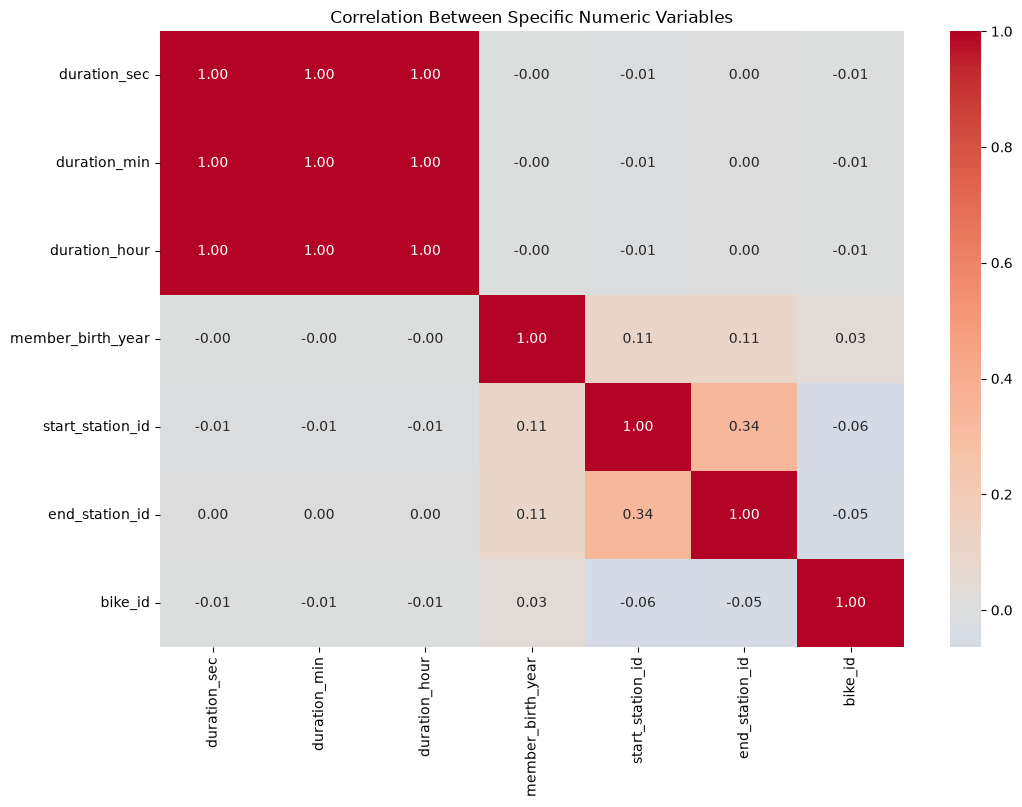

,duration_sec,duration_min,duration_hour,member_birth_year,start_station_id,end_station_id,bike_id
duration_sec,1.00,1.00,1.00,-0.00,-0.01,0.00,-0.01
duration_min,1.00,1.00,1.00,-0.00,-0.01,0.00,-0.01
duration_hour,1.00,1.00,1.00,-0.00,-0.01,0.00,-0.01
member_birth_year,-0.00,-0.00,-0.00,1.00,0.11,0.11,0.03
start_station_id,-0.01,-0.01,-0.01,0.11,1.00,0.34,-0.06
end_station_id,0.00,0.00,0.00,0.11,0.34,1.00,-0.05
bike_id,-0.01,-0.01,-0.01,0.03,-0.06,-0.05,1.00


In [121]:
# Make visualization to easy get insight

specific_cols = [col for col in ["duration_sec", "duration_min", "duration_hour", "member_birth_year", "age", "start_station_id", "end_station_id", "bike_id"] if col in df.columns]
specific_corr = df[specific_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 8)); sns.heatmap(specific_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Specific Numeric Variables"); plt.show(); specific_corr.round(2)


> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- 




- 




# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


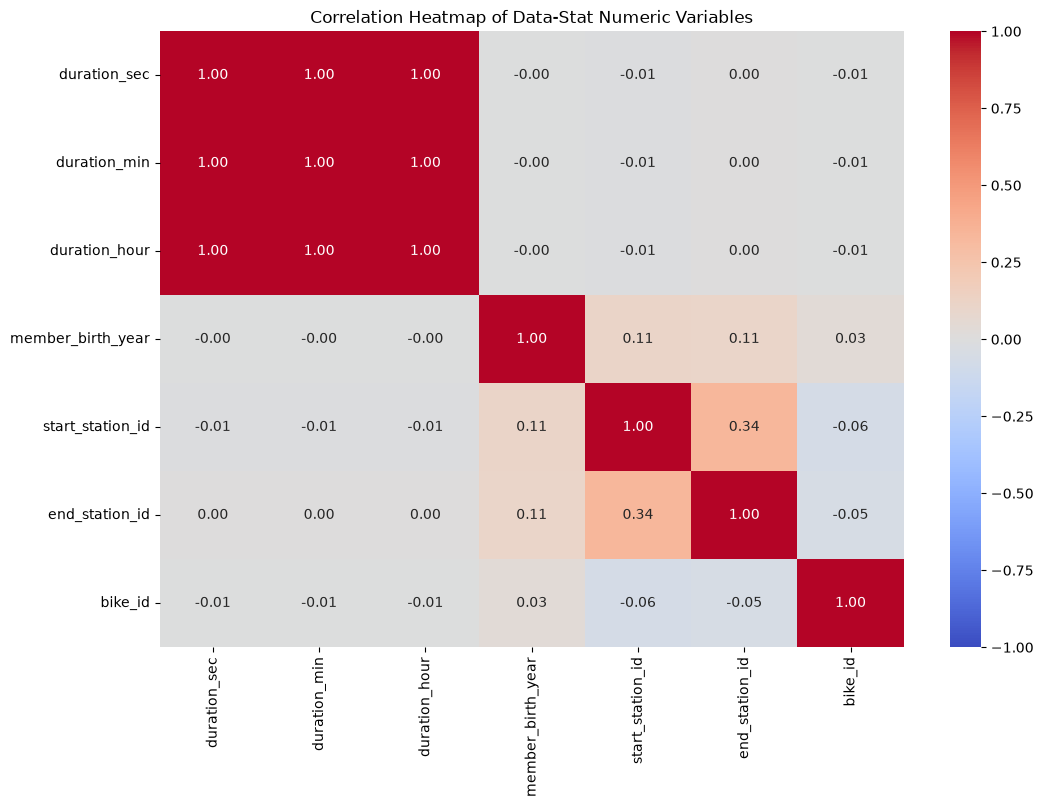

Correlation coefficients:
                   duration_sec  duration_min  duration_hour  \
duration_sec               1.00          1.00           1.00   
duration_min               1.00          1.00           1.00   
duration_hour              1.00          1.00           1.00   
member_birth_year         -0.00         -0.00          -0.00   
start_station_id          -0.01         -0.01          -0.01   
end_station_id             0.00          0.00           0.00   
bike_id                   -0.01         -0.01          -0.01   

                   member_birth_year  start_station_id  end_station_id  \
duration_sec                   -0.00             -0.01            0.00   
duration_min                   -0.00             -0.01            0.00   
duration_hour                  -0.00             -0.01            0.00   
member_birth_year               1.00              0.11            0.11   
start_station_id                0.11              1.00            0.34   
end_station_id   

In [123]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight
data_stat_cols = [col for col in ["duration_sec", "duration_min", "duration_hour", "member_birth_year", "age", "start_station_id", "end_station_id", "bike_id"] if col in df.columns]
data_stat_corr = df[data_stat_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(data_stat_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Data-Stat Numeric Variables"); plt.show()
print("Correlation coefficients:")
print(data_stat_corr.round(2))
print("\nCorrelation percentages:")
print((data_stat_corr * 100).round(1))


> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- Most users were Male.

- The dataset was cleaned by handling missing values, checking duplicates, converting categorical variables, and creating derived features.
- `age`, `duration_min`, and `duration_hour` make the original data easier to analyze.
- Univariate analysis describes user type, bike-share participation, age, gender, and trip-duration distributions.
- Bivariate analysis compares trip duration and age across user types and gender.
- Multivariate analysis shows the expected relationships between duration-unit columns and between birth year and age.



## limitation 
example
- We got missing data which we fix some of them .

- Filled missing values are estimates rather than original observations.
- `bike_id`, `start_station_id`, and `end_station_id` are identifiers; their numerical correlations should not automatically be interpreted as real-world relationships.
- A trip count is not necessarily a count of unique people.
- Extreme trip durations can affect the mean, so medians and distributions are also useful.
